## Data Fetch

In [19]:
import psycopg2
import pandas as pd

# Database connection
def get_db_connection():
    return psycopg2.connect(
        dbname= 'Crypto_Data',
        user= 'postgres',
        password= 'harsh2505',
        host='localhost',
        port= '5432'
        )

# Fetch data as a DataFrame
def fetch_crypto_data():
    conn = get_db_connection()
    query = 'SELECT "timestamp", "price_usd", "market_cap", "volume" FROM crypto_prices ORDER BY "timestamp" ASC'
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# Example usage
df = fetch_crypto_data()
print(df.head())


   timestamp     price_usd    market_cap        volume
0 2024-03-01  61298.216861  1.206725e+12  6.769269e+10
1 2024-03-02  62426.640529  1.227713e+12  3.669919e+10
2 2024-03-03  62067.866802  1.219383e+12  2.519821e+10
3 2024-03-04  63053.105439  1.236312e+12  2.710837e+10
4 2024-03-05  68186.645934  1.333913e+12  7.455171e+10


/var/folders/pk/p3wpx48n6vjf1t4q619jt4k40000gn/T/ipykernel_34342/3890076884.py:18: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



## Importing Libraries

In [11]:
pip install setuptools

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install setuptools


Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from keras_tuner import RandomSearch
import pandas as pd
import numpy as np


In [10]:
pip install "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.


In [3]:
import plotly.express as px
import pandas as pd


# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create an interactive line chart
fig = px.line(df, x="timestamp", y="price_usd", title="Bitcoin Price Trend", labels={"price_usd": "Price (USD)"})

# Show the interactive plot
fig.show()


In [4]:
import plotly.graph_objects as go

# Create subplots
fig = go.Figure()

# Price Line
# fig.add_trace(go.Scatter(x=df["timestamp"], y=df["price_usd"], mode="lines", name="Price (USD)", line=dict(color='blue')))

# Market Cap Line
fig.add_trace(go.Scatter(x=df["timestamp"], y=df["market_cap"], mode="lines", name="Market Cap", line=dict(color='green')))

# Volume Line
fig.add_trace(go.Scatter(x=df["timestamp"], y=df["volume"], mode="lines", name="Trading Volume", line=dict(color='red')))

# Layout
fig.update_layout(title="Crypto Market Trends", xaxis_title="Date", yaxis_title="Value", hovermode="x unified")

# Show Plot
fig.show()


In [5]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df["timestamp"],
    open=df["price_usd"],  # Replace with your 'open' column
    high=df["price_usd"] + 500,  # Simulated high values
    low=df["price_usd"] - 500,  # Simulated low values
    close=df["price_usd"],  # Replace with 'close' if available
    name="Bitcoin Candlestick Chart"
)])

fig.update_layout(title="Bitcoin Candlestick Chart", xaxis_title="Date", yaxis_title="Price (USD)")
fig.show()


In [8]:
df

,timestamp,price_usd,market_cap,volume
0,2024-03-01,61298.216861,1.206725e+12,6.769269e+10
1,2024-03-02,62426.640529,1.227713e+12,3.669919e+10
2,2024-03-03,62067.866802,1.219383e+12,2.519821e+10
3,2024-03-04,63053.105439,1.236312e+12,2.710837e+10
4,2024-03-05,68186.645934,1.333913e+12,7.455171e+10
...,...,...,...,...
350,2025-02-14,96561.663999,1.914315e+12,2.908437e+10
351,2025-02-15,97488.481485,1.931657e+12,3.228991e+10
352,2025-02-16,97569.951694,1.934308e+12,1.421531e+10
353,2025-02-17,96149.348455,1.905012e+12,1.363479e+10


In [3]:
df = df[['price_usd', 'market_cap', 'volume']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)


NameError: name 'MinMaxScaler' is not defined

In [4]:
def create_dataset(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, 0])  # Predicting 'price_usd'
    return np.array(X), np.array(y)

In [27]:
time_steps = 60
X, y = create_dataset(scaled_data, time_steps)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [18]:
split_ratio = 0.8
split = int(len(X) * split_ratio)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [28]:
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))

/Users/harshshivhare/Documents/Real-Time-Crypto-Price-Prediction/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [29]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')


In [30]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0918 - val_loss: 0.0487
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0185 - val_loss: 0.0340
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0120 - val_loss: 0.0662
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0118 - val_loss: 0.0080
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0082 - val_loss: 0.0280
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0079 - val_loss: 0.0111
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0084 - val_loss: 0.0066
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0056 - val_loss: 0.0105
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0067 - val_loss: 0.0073
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0058 - val_loss: 0.0070
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0060 - val_loss: 0.0070
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0057 - val_lo

In [31]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


In [32]:
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 2))), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((len(y_pred), 2))), axis=1))[:, 0]

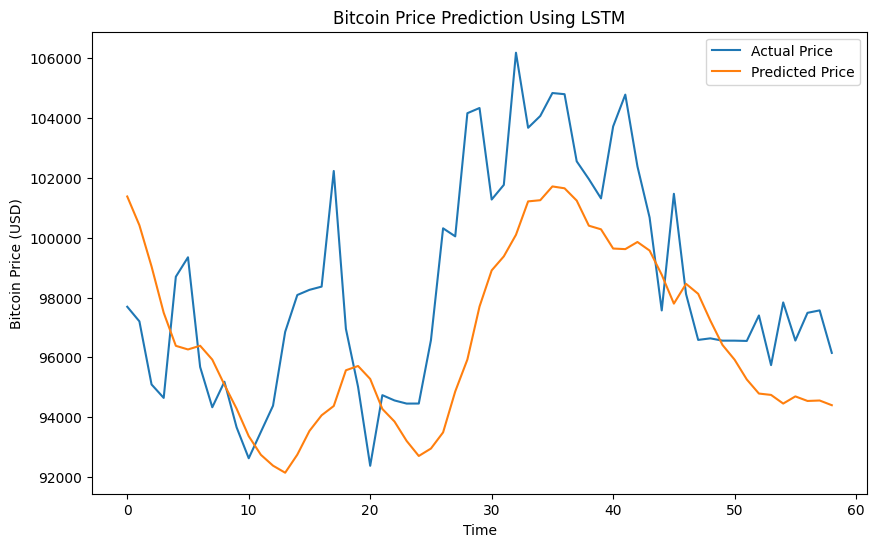

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using LSTM')
plt.legend()
plt.show()

In [6]:
import plotly.express as px
import pandas as pd


# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create an interactive line chart
fig = px.line(df, x="timestamp", y="price_usd", title="Bitcoin Price Trend", labels={"price_usd": "Price (USD)"})

# Show the interactive plot
fig.show()


In [7]:
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')

NameError: name 'np' is not defined

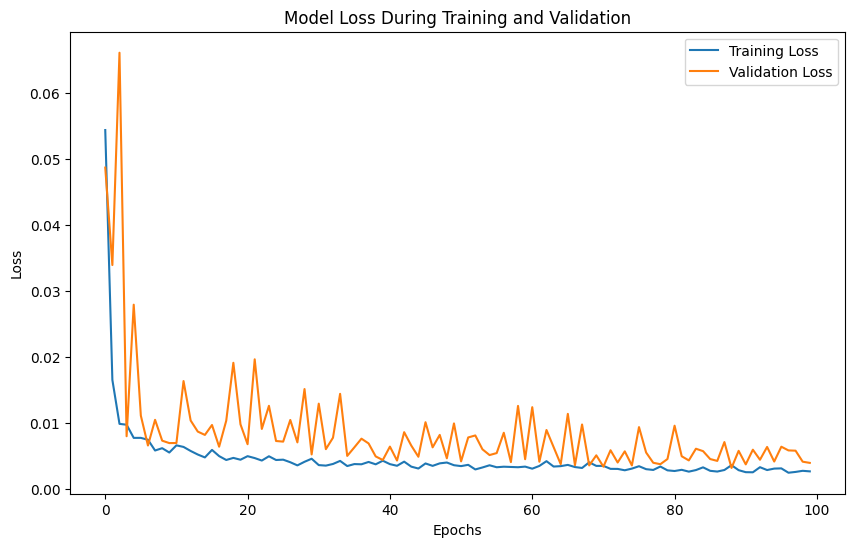

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

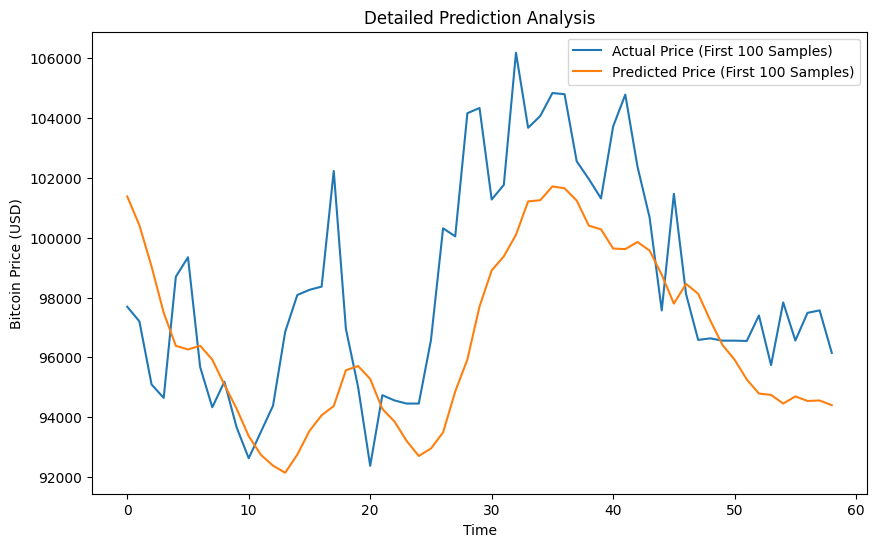

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional


# Convert date to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by date
df = df.sort_values('timestamp')

# Feature engineering with moving averages
df['MA7'] = df['price_usd'].rolling(window=7).mean()
df['MA21'] = df['price_usd'].rolling(window=21).mean()
df = df[['price_usd', 'market_cap', 'volume', 'MA7', 'MA21']].dropna()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Define a function to create a dataset with time steps
def create_dataset(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, 0])  # Predicting 'price_usd'
    return np.array(X), np.array(y)

# Prepare the training and testing datasets
time_steps = 60
X, y = create_dataset(scaled_data, time_steps)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [20]:
df

,price_usd,market_cap,volume,MA7,MA21
20,67819.055707,1.332594e+12,7.083680e+10,67470.862948,67109.774511
21,65535.978448,1.287348e+12,4.839366e+10,66630.283898,67311.572682
22,63509.044965,1.247366e+12,4.243660e+10,65774.752723,67363.115750
23,64285.802791,1.264722e+12,2.548993e+10,65630.965508,67468.731750
24,67310.983268,1.323456e+12,2.809832e+10,65471.760881,67671.487837
...,...,...,...,...,...
350,96561.663999,1.914315e+12,2.908437e+10,96743.297733,99742.273571
351,97488.481485,1.931657e+12,3.228991e+10,96876.158473,99392.430188
352,97569.951694,1.934308e+12,1.421531e+10,97020.689054,99048.330708
353,96149.348455,1.905012e+12,1.363479e+10,96963.656168,98743.430694


## Model Training

Trial 10 Complete [00h 00m 16s]
val_loss: 0.0027274019084870815

Best val_loss So Far: 0.002099200850352645
Total elapsed time: 00h 02m 35s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step
Root Mean Squared Error: 2394.3471
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - loss: 0.0057 - val_loss: 0.0024
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0041 - val_loss: 0.0029
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0053 - val_loss: 0.0044
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0044 - val_loss: 0.0021
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0044 - val_loss: 0.0073
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.0040 - val_loss: 0.0034
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0041 - val_loss: 0.0052
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.0037 - val_loss: 0.0030


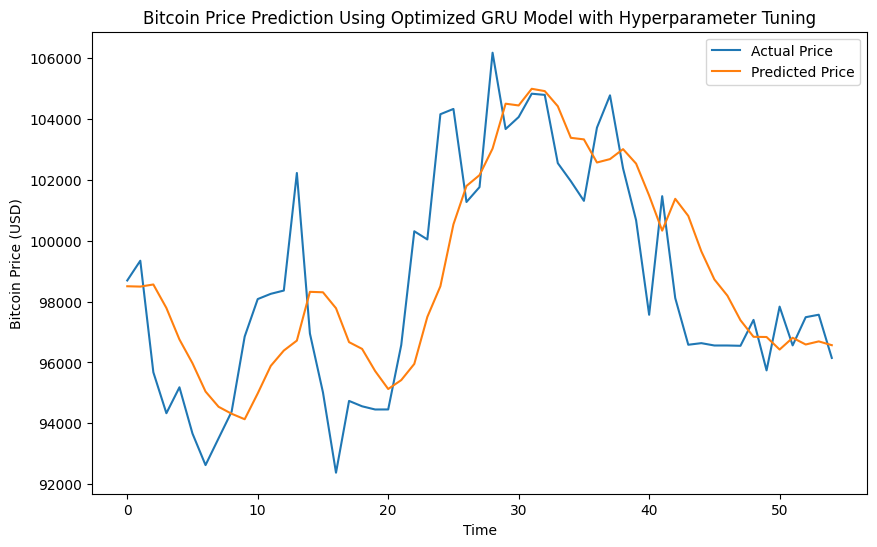

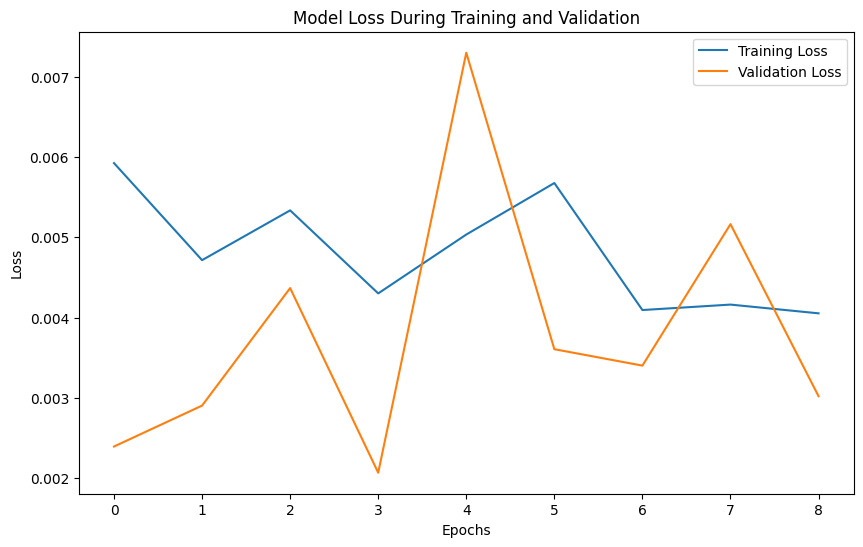

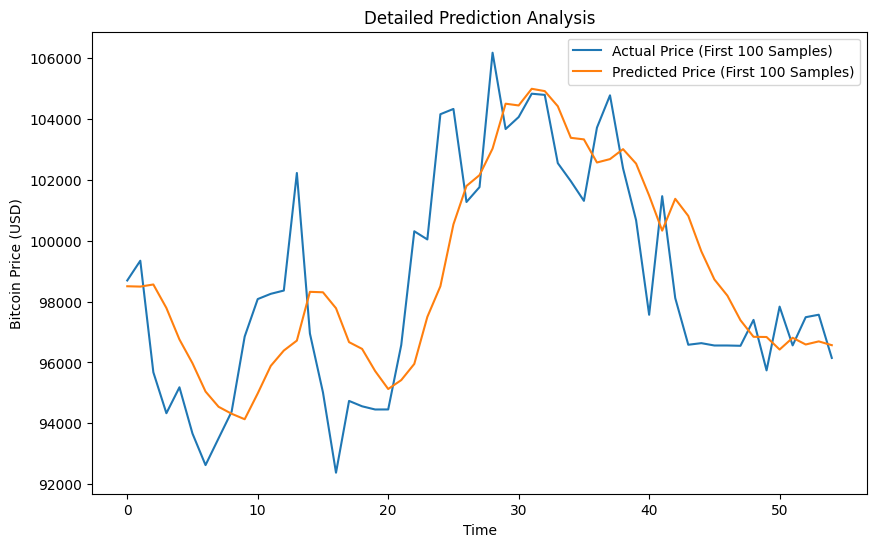

In [33]:
def build_model(hp):
    model = Sequential()
    model.add(Bidirectional(GRU(hp.Int('units1', min_value=50, max_value=200, step=50), return_sequences=True,
                               input_shape=(X_train.shape[1], X_train.shape[2]))))
    model.add(Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Bidirectional(GRU(hp.Int('units2', min_value=25, max_value=100, step=25), return_sequences=True)))
    model.add(Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(GRU(hp.Int('units3', min_value=10, max_value=50, step=10), return_sequences=False))
    model.add(Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                  loss='mean_squared_error')
    return model

# Hyperparameter tuning
tuner = RandomSearch(build_model,
                     objective='val_loss',
                     max_trials=10,
                     executions_per_trial=1,
                     directory='hyperparameter_tuning',
                     project_name='crypto_price_prediction')

tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
             callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

# Get the best model
best_gru_model = tuner.get_best_models(num_models=1)[0]


# Make predictions
y_pred = best_gru_model.predict(X_test)

num_features = df.shape[1]  # total number of features you scaled
zeros_pred = np.zeros((len(y_pred), num_features - 1))
zeros_test = np.zeros((len(y_test), num_features - 1))


# Inverse scaling to get actual prices
# y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 4))), axis=1))[:, 0]
# y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), np.zeros((len(y_pred), 4))), axis=1))[:, 0]
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), zeros_test), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), zeros_pred), axis=1))[:, 0]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')
history = best_gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)]
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using Optimized GRU Model with Hyperparameter Tuning')
plt.legend()
plt.show()

# Additional plots for research paper
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()

In [30]:
history = best_gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)]
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - loss: 0.0021 - val_loss: 0.0032
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0019 - val_loss: 0.0040
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0021 - val_loss: 0.0096
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0021 - val_loss: 0.0054
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0019 - val_loss: 0.0057
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.0019 - val_loss: 0.0062
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.0018 - val_loss: 0.0023


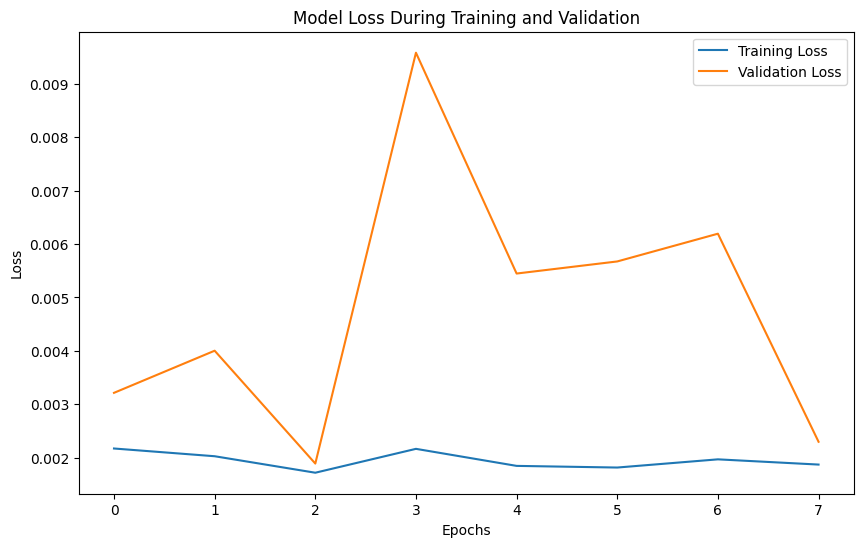

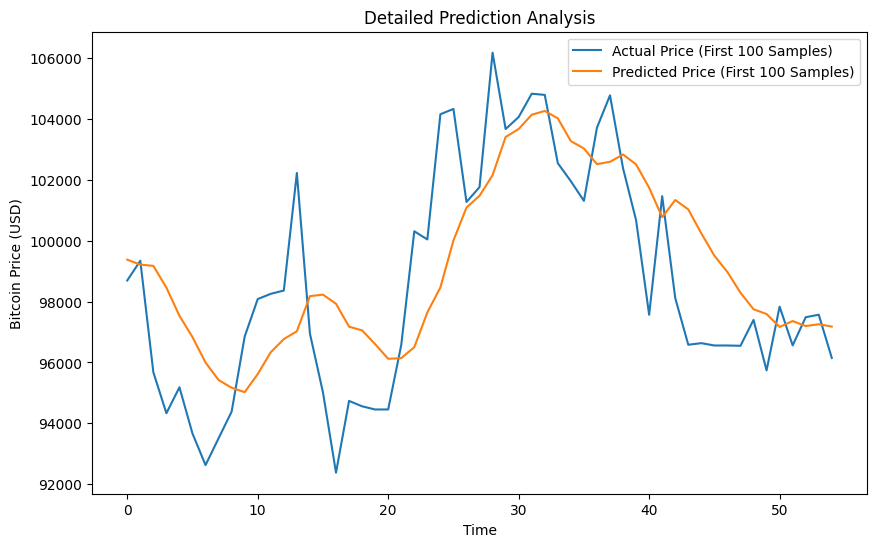

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()

In [8]:
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Percentage Error: {mape * 100:.2f}%')

NameError: name 'np' is not defined

In [7]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


In [10]:
from sklearn.metrics import mean_absolute_error

# Calculate accuracy metrics
# mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
# # accuracy = 100 - np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

# print(f'Mean Absolute Error (MAE): {mae:.4f}')
# # print(f'Accuracy: {accuracy:.2f}%')

Reloading Tuner from hyperparameter_tuning/crypto_lstm_prediction/tuner0.json


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 426ms/step
Root Mean Squared Error: 2773.3735


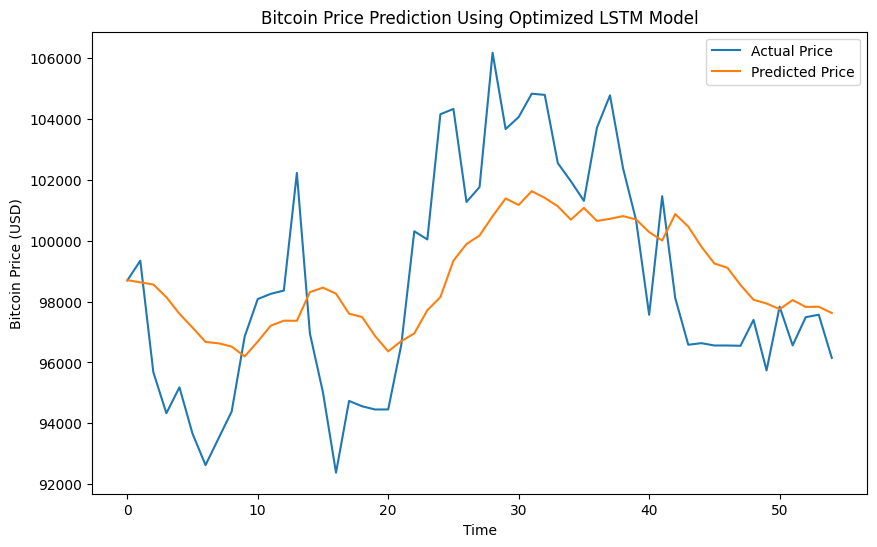

History not attached to the model, skipping loss plots.


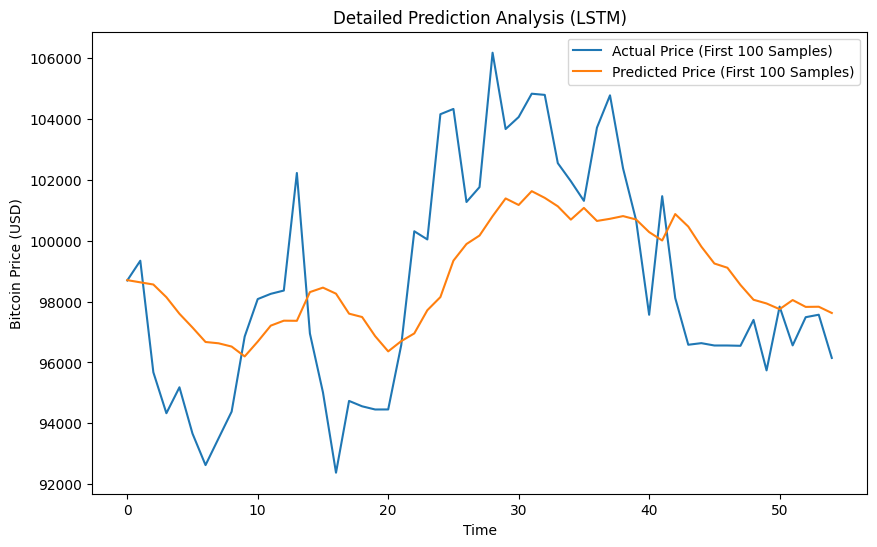

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras_tuner.tuners import RandomSearch
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define LSTM-based model for tuning
def build_lstm_model(hp):
    model = Sequential()
    model.add(Bidirectional(LSTM(
        hp.Int('units1', min_value=50, max_value=200, step=50), return_sequences=True),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Bidirectional(LSTM(
        hp.Int('units2', min_value=25, max_value=100, step=25), return_sequences=True)))
    model.add(Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(LSTM(hp.Int('units3', min_value=10, max_value=50, step=10), return_sequences=False))
    model.add(Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mean_squared_error'
    )
    return model

# Set up the tuner
tuner = RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='hyperparameter_tuning',
    project_name='crypto_lstm_prediction'
)

# Search for best hyperparameters
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
             callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

# Retrieve the best model
best_lstm_model = tuner.get_best_models(num_models=1)[0]

# Predict on test set
y_pred = best_lstm_model.predict(X_test)

# Inverse scaling
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), df.shape[1]-1))), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), np.zeros((len(y_pred), df.shape[1]-1))), axis=1))[:, 0]

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using Optimized LSTM Model')
plt.legend()
plt.show()

# Training and validation loss (if saved in history)
try:
    history = tuner.get_best_trials(num_trials=1)[0].metrics
    plt.figure(figsize=(10, 6))
    plt.plot(best_lstm_model.history.history['loss'], label='Training Loss')
    plt.plot(best_lstm_model.history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Model Loss During Training and Validation')
    plt.legend()
    plt.show()
except:
    print("History not attached to the model, skipping loss plots.")

# Detailed analysis on first 100 samples
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis (LSTM)')
plt.legend()
plt.show()


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print(f"📊 LSTM Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


📊 LSTM Model Performance:
Root Mean Squared Error (RMSE): 2773.3735
Mean Absolute Error (MAE): 2340.0113
R² Score: 0.4203


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
📊 Ensemble Performance:
RMSE: 2489.0370
MAE : 1981.6628
R²  : 0.5330


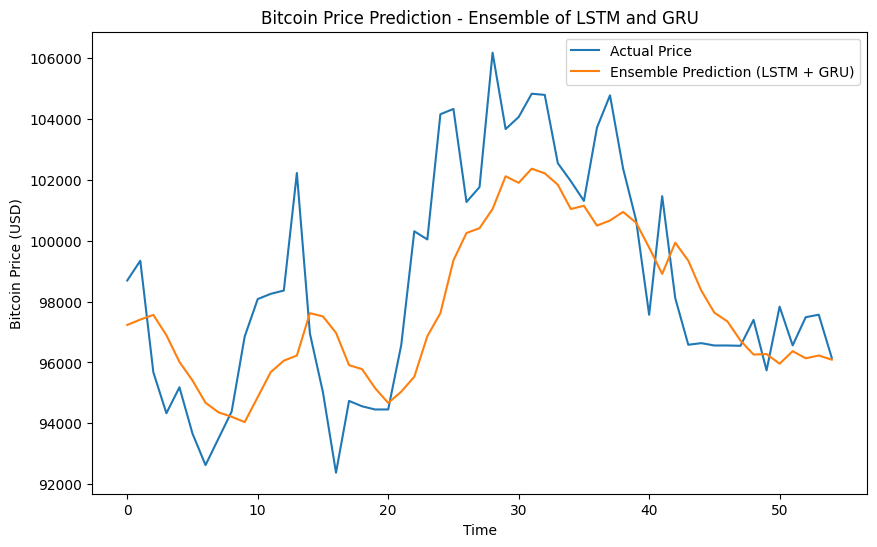

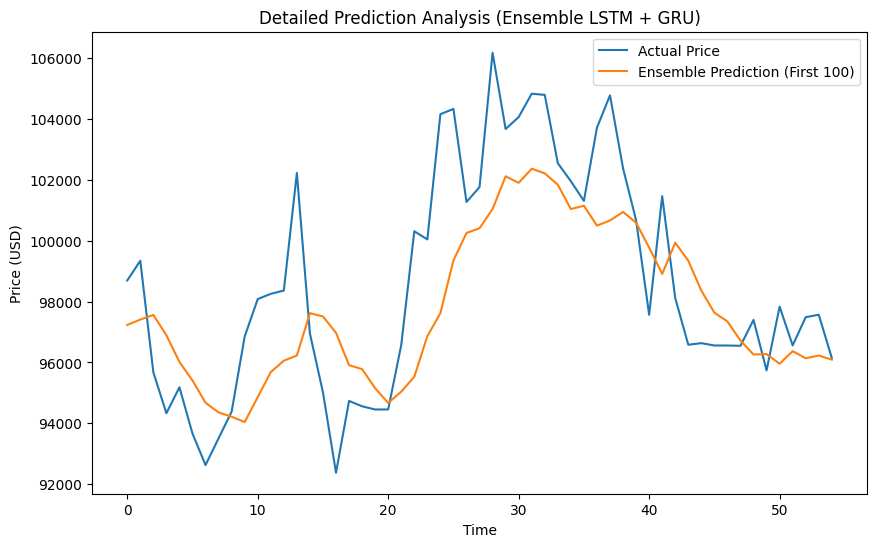

In [34]:
# Make predictions from both models
y_pred_lstm = best_lstm_model.predict(X_test)
y_pred_gru = best_gru_model.predict(X_test)

# Average their predictions
y_pred_ensemble = (y_pred_lstm + y_pred_gru) / 2

# Inverse scaling
y_test_rescaled = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), df.shape[1]-1))), axis=1)
)[:, 0]

y_pred_ensemble_rescaled = scaler.inverse_transform(
    np.concatenate((y_pred_ensemble.reshape(-1, 1), np.zeros((len(y_pred_ensemble), df.shape[1]-1))), axis=1)
)[:, 0]

# Evaluate Ensemble Performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_ensemble_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_ensemble_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_ensemble_rescaled)

print(f"📊 Ensemble Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# Plot Ensemble Predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_ensemble_rescaled, label='Ensemble Prediction (LSTM + GRU)')
plt.title('Bitcoin Price Prediction - Ensemble of LSTM and GRU')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.show()

# Detailed comparison on first 100 samples
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price')
plt.plot(y_pred_ensemble_rescaled[:100], label='Ensemble Prediction (First 100)')
plt.title('Detailed Prediction Analysis (Ensemble LSTM + GRU)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


## Time Series Model

In [5]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


In [11]:
from prophet import Prophet

# Log-transform price
df_prophet = df[['timestamp', 'price_usd']].rename(columns={'timestamp': 'ds', 'price_usd': 'y'})
df_prophet['y'] = np.log(df_prophet['y'])

# Train-test split
split = int(len(df_prophet) * 0.8)
train_prophet = df_prophet.iloc[:split]
test_prophet = df_prophet.iloc[split:]

# Model with tuned changepoint flexibility
model_prophet = Prophet(
    daily_seasonality=True,
    changepoint_prior_scale=0.3
)
model_prophet.fit(train_prophet)

# Predict
future = model_prophet.make_future_dataframe(periods=len(test_prophet))
forecast = model_prophet.predict(future)

# Inverse transform predictions
forecast['yhat'] = np.exp(forecast['yhat'])

# Evaluation
forecast_subset = forecast[['ds', 'yhat']].iloc[-len(test_prophet):]
actuals = np.exp(test_prophet['y'])  # also inverse actuals for fair comparison

rmse = np.sqrt(mean_squared_error(actuals, forecast_subset['yhat']))
mae = mean_absolute_error(actuals, forecast_subset['yhat'])
r2 = r2_score(actuals, forecast_subset['yhat'])

print(f"📊 Improved Prophet Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")


16:32:28 - cmdstanpy - INFO - Chain [1] start processing
16:32:28 - cmdstanpy - INFO - Chain [1] done processing


📊 Improved Prophet Performance:
RMSE: 57792.3000
MAE : 50322.6795
R²  : -249.5230


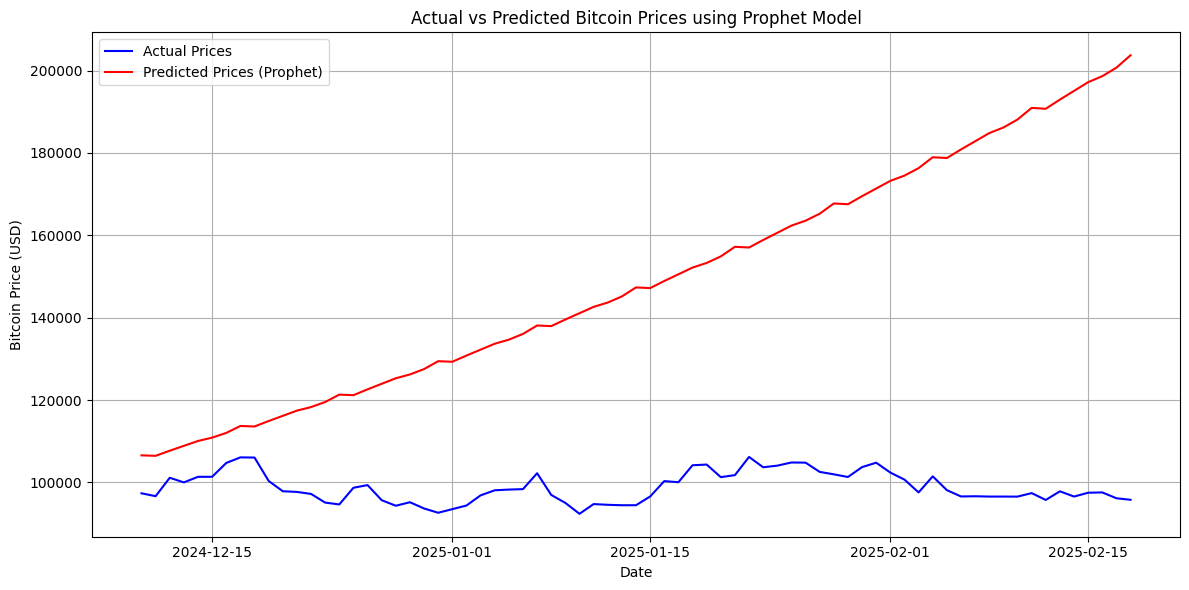

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have forecast_subset and actuals from your Prophet model

# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(forecast_subset['ds'], actuals, label='Actual Prices', color='blue')
plt.plot(forecast_subset['ds'], forecast_subset['yhat'], label='Predicted Prices (Prophet)', color='red')
plt.title('Actual vs Predicted Bitcoin Prices using Prophet Model')
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
df

NameError: name 'df' is not defined

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['price_usd', 'market_cap', 'volume']])  # or whatever features you want


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def build_model(hp):
    model = Sequential()

    # CNN Block
    model.add(Conv1D(
        filters=hp.Choice('filters', [32, 64, 128]),
        kernel_size=hp.Choice('kernel_size', [2, 3, 5]),
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout_cnn', 0.1, 0.5, step=0.1)))

    # LSTM Block
    model.add(LSTM(
        units=hp.Int('lstm_units', 32, 128, step=32),
        return_sequences=False
    ))
    model.add(Dropout(hp.Float('dropout_lstm', 0.1, 0.5, step=0.1)))

    # Dense
    model.add(Dense(hp.Int('dense_units', 25, 100, step=25), activation='relu'))
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mean_squared_error'
    )

    return model

# Tuner setup
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='cnn_lstm_tuning',
    project_name='crypto_cnn_lstm'
)

# Search for best hyperparameters
tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

# Best model
best_cnn_lstm = tuner.get_best_models(num_models=1)[0]
y_pred = best_cnn_lstm.predict(X_test)

# Inverse scaling
num_features = scaled_data.shape[1]
zeros_pred = np.zeros((len(y_pred), num_features - 1))
zeros_test = np.zeros((len(y_test), num_features - 1))

y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), zeros_test), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), zeros_pred), axis=1))[:, 0]

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print(f"📊 Tuned CNN-LSTM Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")


Trial 10 Complete [00h 00m 21s]
val_loss: 0.008039554581046104

Best val_loss So Far: 0.00394245283678174
Total elapsed time: 00h 02m 34s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
📊 Tuned CNN-LSTM Performance:
RMSE: 3281.2805
MAE : 2770.2258
R²  : 0.1624


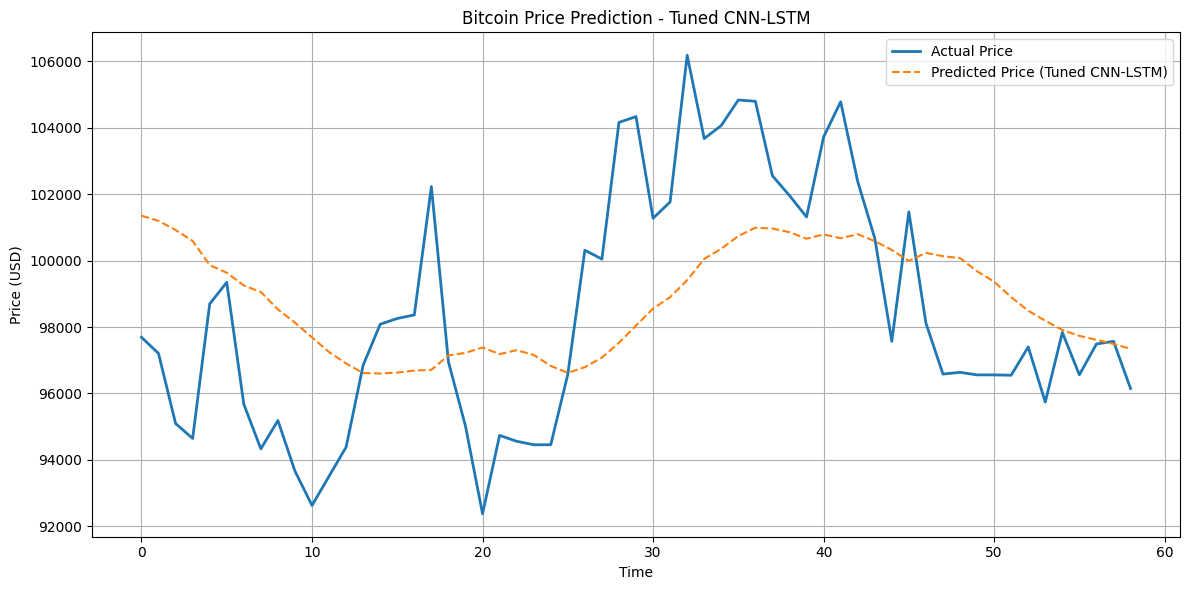

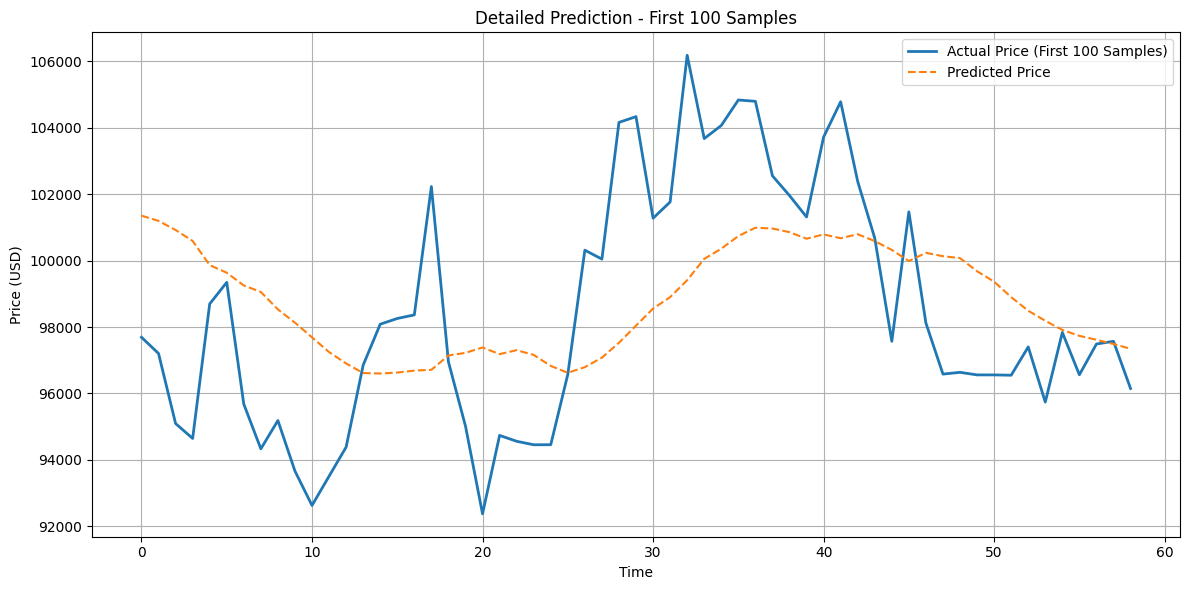

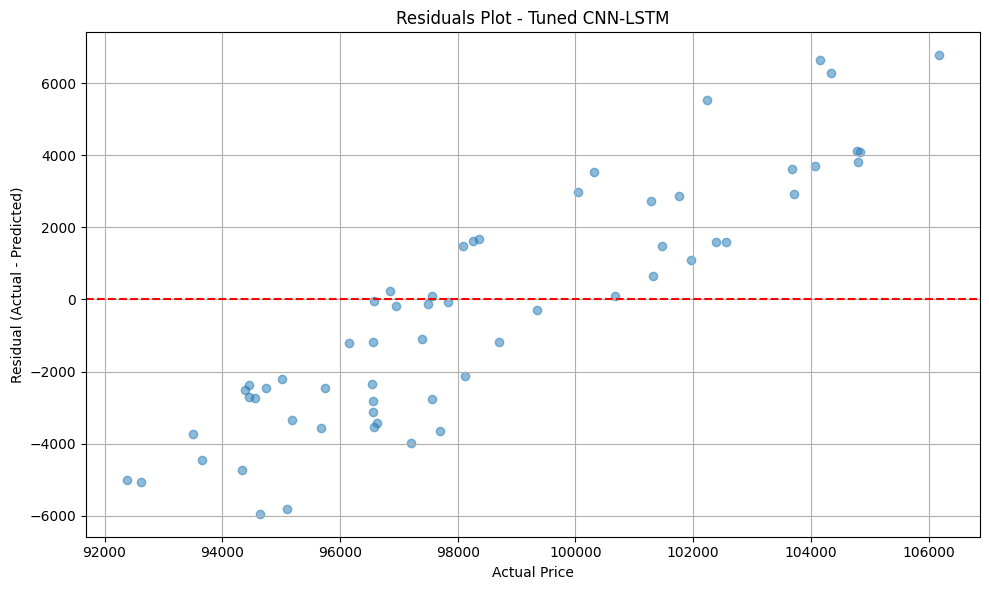

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual Price', linewidth=2)
plt.plot(y_pred_rescaled, label='Predicted Price (Tuned CNN-LSTM)', linestyle='--')
plt.title('Bitcoin Price Prediction - Tuned CNN-LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)', linewidth=2)
plt.plot(y_pred_rescaled[:100], label='Predicted Price', linestyle='--')
plt.title('Detailed Prediction - First 100 Samples')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


residuals = y_test_rescaled - y_pred_rescaled

plt.figure(figsize=(10, 6))
plt.scatter(y_test_rescaled, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Plot - Tuned CNN-LSTM')
plt.xlabel('Actual Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.tight_layout()
plt.show()



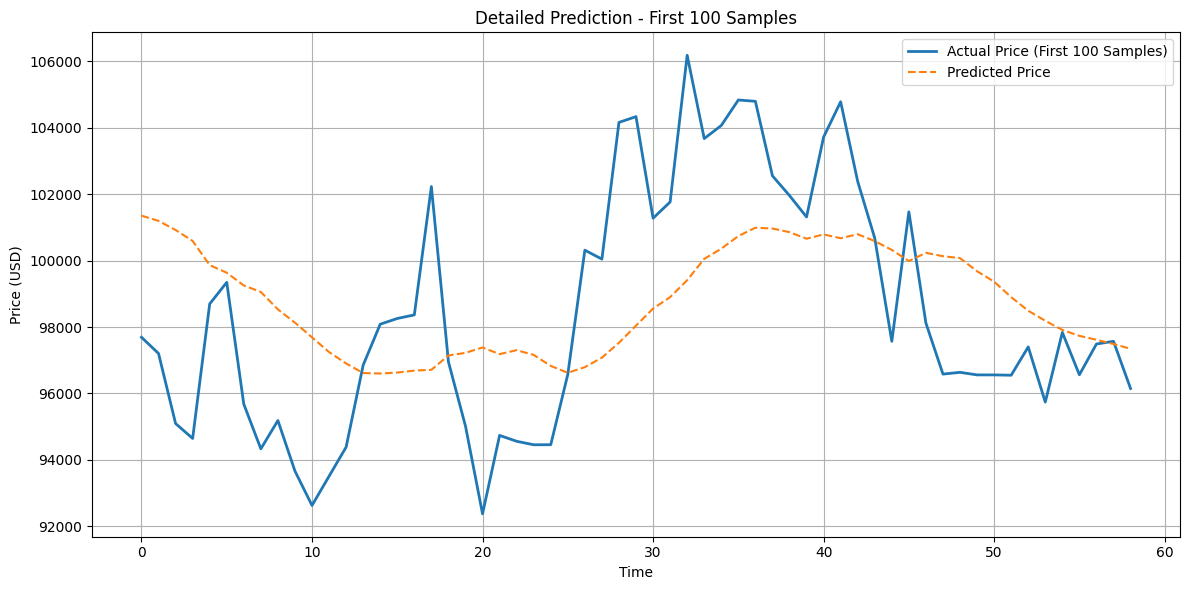

In [54]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make GRU predictions
y_pred_gru = best_gru_model.predict(X_test)

# Inverse transform
num_features = scaled_data.shape[1]
zeros_pred_gru = np.zeros((len(y_pred_gru), num_features - 1))
zeros_test_gru = np.zeros((len(y_test), num_features - 1))

y_pred_rescaled_gru = scaler.inverse_transform(np.concatenate((y_pred_gru.reshape(-1, 1), zeros_pred_gru), axis=1))[:, 0]
y_test_rescaled_gru = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), zeros_test_gru), axis=1))[:, 0]

# Metrics
mae_gru = mean_absolute_error(y_test_rescaled_gru, y_pred_rescaled_gru)
r2_gru = r2_score(y_test_rescaled_gru, y_pred_rescaled_gru)

print(f"📊 GRU Metrics:")
print(f"MAE: {mae_gru:.4f}")
print(f"R² : {r2_gru:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step
📊 GRU Metrics:
MAE: 2224.3330
R² : 0.3777


In [55]:
# Make LSTM predictions
y_pred_lstm = best_lstm_model.predict(X_test)

# Inverse transform
zeros_pred_lstm = np.zeros((len(y_pred_lstm), num_features - 1))
zeros_test_lstm = np.zeros((len(y_test), num_features - 1))

y_pred_rescaled_lstm = scaler.inverse_transform(np.concatenate((y_pred_lstm.reshape(-1, 1), zeros_pred_lstm), axis=1))[:, 0]
y_test_rescaled_lstm = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), zeros_test_lstm), axis=1))[:, 0]

# Metrics
mae_lstm = mean_absolute_error(y_test_rescaled_lstm, y_pred_rescaled_lstm)
r2_lstm = r2_score(y_test_rescaled_lstm, y_pred_rescaled_lstm)

print(f"📊 LSTM Metrics:")
print(f"MAE: {mae_lstm:.4f}")
print(f"R² : {r2_lstm:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
📊 LSTM Metrics:
MAE: 2340.0113
R² : 0.4203


### ARMIA

In [18]:
df

,price_usd,market_cap,volume,MA7,MA21
20,67819.055707,1.332594e+12,7.083680e+10,67470.862948,67109.774511
21,65535.978448,1.287348e+12,4.839366e+10,66630.283898,67311.572682
22,63509.044965,1.247366e+12,4.243660e+10,65774.752723,67363.115750
23,64285.802791,1.264722e+12,2.548993e+10,65630.965508,67468.731750
24,67310.983268,1.323456e+12,2.809832e+10,65471.760881,67671.487837
...,...,...,...,...,...
350,96561.663999,1.914315e+12,2.908437e+10,96743.297733,99742.273571
351,97488.481485,1.931657e+12,3.228991e+10,96876.158473,99392.430188
352,97569.951694,1.934308e+12,1.421531e+10,97020.689054,99048.330708
353,96149.348455,1.905012e+12,1.363479e+10,96963.656168,98743.430694


📊 ARIMA Model Performance:
Root Mean Squared Error (RMSE): 4374.1942
Mean Absolute Error (MAE): 3768.7947
R² Score: -0.4352


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



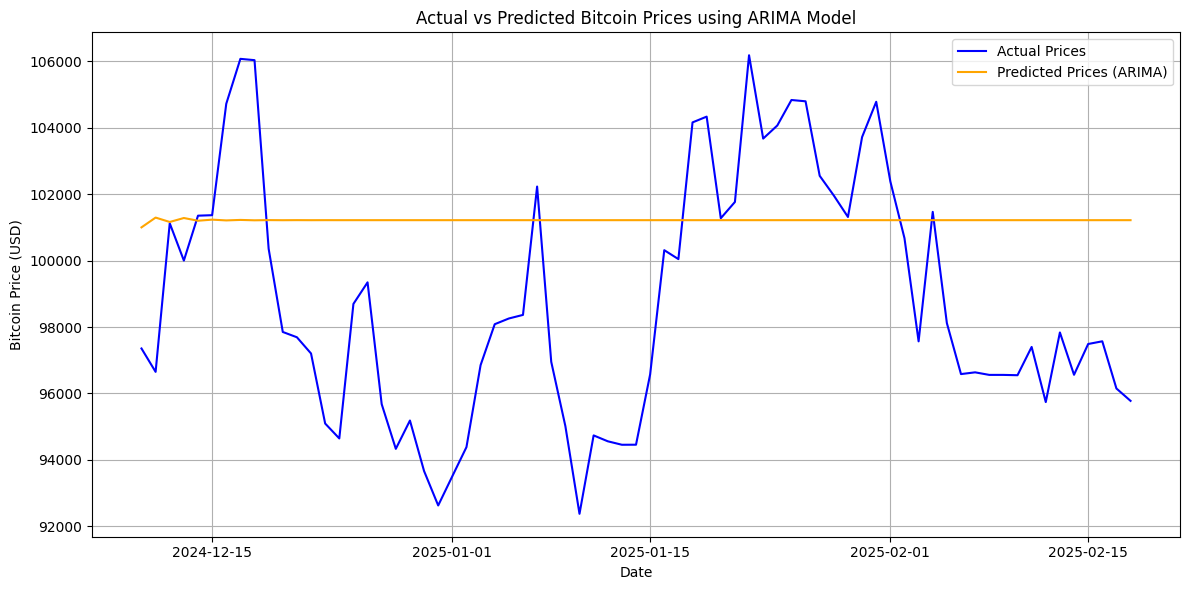

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you already have your DataFrame 'df' with 'timestamp' and 'price_usd'

# Prepare time series
df_arima = df.copy()
df_arima['timestamp'] = pd.to_datetime(df_arima['timestamp'])
df_arima.set_index('timestamp', inplace=True)

# Use only price column
series = df_arima['price_usd']

# Train-test split (80-20)
split = int(len(series) * 0.8)
train_arima, test_arima = series[:split], series[split:]

# Fit ARIMA model
model_arima = ARIMA(train_arima, order=(5,1,0))  # (p,d,q) — basic ARIMA settings
model_fit = model_arima.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test_arima))

# Evaluation
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast))
mae_arima = mean_absolute_error(test_arima, forecast)
r2_arima = r2_score(test_arima, forecast)

print(f"📊 ARIMA Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse_arima:.4f}")
print(f"Mean Absolute Error (MAE): {mae_arima:.4f}")
print(f"R² Score: {r2_arima:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test_arima.index, test_arima.values, label='Actual Prices', color='blue')
plt.plot(test_arima.index, forecast, label='Predicted Prices (ARIMA)', color='orange')
plt.title('Actual vs Predicted Bitcoin Prices using ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pi

### XGBoost

📊 XGBoost Model Performance:
Root Mean Squared Error (RMSE): 3535.6467
Mean Absolute Error (MAE): 2779.4923
R² Score: 0.0623


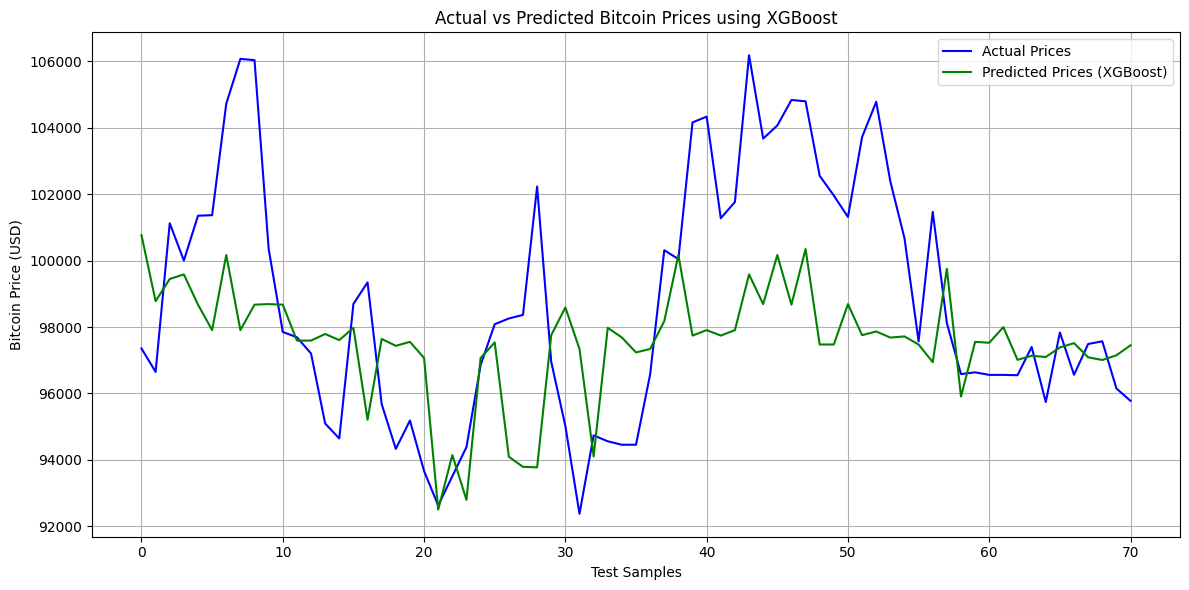

In [24]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Assume df has ['timestamp', 'price_usd', 'volume', 'market_cap']
df_ml = df.copy()
df_ml['target'] = df_ml['price_usd'].shift(-1)  # Predict next day price
df_ml.dropna(inplace=True)

# Features
X = df_ml[['price_usd', 'volume', 'market_cap']]
y = df_ml['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Model
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
model_xgb.fit(X_train, y_train)

# Predict
y_pred = model_xgb.predict(X_test)

# Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgb = mean_absolute_error(y_test, y_pred)
r2_xgb = r2_score(y_test, y_pred)

print(f"📊 XGBoost Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices (XGBoost)', color='green')
plt.title('Actual vs Predicted Bitcoin Prices using XGBoost')
plt.xlabel('Test Samples')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
